In [1]:
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

In [2]:
from libpysal.weights import Queen, Rook

In [ ]:
gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp")

# Make sure the shape file has geometry column
assert 'geometry' in gdf.columns

In [4]:
# Construct a weighted graph based on Queen adjacency (shared edges or points)
w_Q = Queen.from_dataframe(gdf)

# Construct a weighted graph based on Rook adjacency (shared edges)
w_R = Rook.from_dataframe(gdf)

# Extracte the adjacency dictionary
adj_dict_Q = w_Q.neighbors
adj_dict_R = w_R.neighbors

C:\Users\wbwha\AppData\Local\Temp\ipykernel_8228\2033338950.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_Q = Queen.from_dataframe(gdf)
C:\Users\wbwha\AppData\Local\Temp\ipykernel_8228\2033338950.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_R = Rook.from_dataframe(gdf)


In [5]:
# Calculate the number of neighbors for each LSOA
lsoa_degree_Q = {k: len(v) for k, v in adj_dict_Q.items()}
degree_series_Q = pd.Series(lsoa_degree_Q)

lsoa_degree_R = {k: len(v) for k, v in adj_dict_R.items()}
degree_series_R = pd.Series(lsoa_degree_R)

# Summary
print(degree_series_Q.describe())
print(degree_series_R.describe())

count    4994.000000
mean        5.979175
std         1.628029
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        20.000000
dtype: float64
count    4994.000000
mean        5.900681
std         1.597285
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        20.000000
dtype: float64


In [16]:
# Identify LSOAs with only one neighbor under Queen and Rook adjacency
low_degree_ids_Q = [k for k, v in lsoa_degree_Q.items() if v == 1]
low_degree_ids_R = [k for k, v in lsoa_degree_R.items() if v == 1]

# Filter the corresponding geometries from the GeoDataFrame
low_degree_gdf_Q = gdf.iloc[low_degree_ids_Q]
low_degree_gdf_R = gdf.iloc[low_degree_ids_R]

Number of LSOAs with only one neighbor (Queen): 3
Number of LSOAs with only one neighbor (Rook): 3


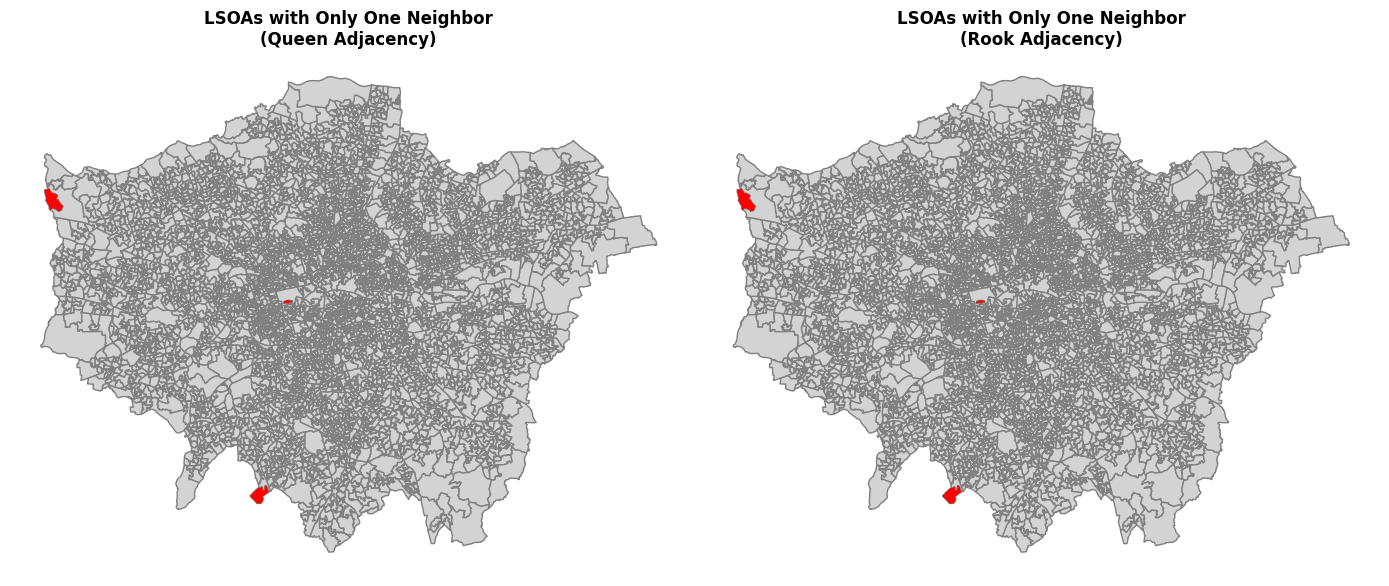

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Plot for Queen adjacency
gdf.plot(ax=axes[0], color='lightgrey', edgecolor='grey')
low_degree_gdf_Q.plot(ax=axes[0], color='red')
axes[0].set_title("LSOAs with Only One Neighbor\n(Queen Adjacency)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot for Rook adjacency
gdf.plot(ax=axes[1], color='lightgrey', edgecolor='grey')
low_degree_gdf_R.plot(ax=axes[1], color='red')
axes[1].set_title("LSOAs with Only One Neighbor\n(Rook Adjacency)", fontsize=12, fontweight='bold')
axes[1].axis('off')

# Print count of low-degree LSOAs
print("Number of LSOAs with only one neighbor (Queen):", len(low_degree_gdf_Q))
print("Number of LSOAs with only one neighbor (Rook):", len(low_degree_gdf_R))

plt.tight_layout()
plt.show()